# Задание 3. Среднее время в пути с окружной скоростной трассой

Прямоугольник $R=[0,1]\times[0,0.6]$, скоростная окружность
$C=\{(c_1,c_2)\in R:\ c_1^2+c_2^2=\tfrac14\}$ — это четверть окружности
радиуса $\tfrac12$ с центром в начале координат: дуга от $(0.5,\,0)$ до
$(0,\,0.5)$ (её верхняя точка $(0,0.5)$ лежит внутри $R$, так как $0.5<0.6$).

Два маршрута из $a\in R$ в $b\in R$:

* прямой: $t_D=|a-b|$;
* через трассу: $t_E=|a-\tilde a|+|\tilde b-b|$, где $\tilde a,\tilde b$ —
  ближайшие к $a$ и $b$ точки окружности $C$ (время движения по окружности
  пренебрежимо мало).

Итоговое время в пути: $t=\min(t_D,t_E)$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import qmc

plt.rcParams.update(
    {"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3}
)

R_X, R_Y = 1.0, 0.6      # границы прямоугольника
RAD = 0.5                 # радиус скоростной окружности


def proj(p):
    """Ближайшая точка окружности радиуса RAD для точки p."""
    p = np.asarray(p, dtype=float)
    r = np.hypot(p[..., 0], p[..., 1])
    out = np.array(p, dtype=float, copy=True)
    nz = r > 0
    out[nz] = p[nz] / r[nz, None] * RAD
    return out                          # для p = (0,0) подходит любая точка круга


def t_direct(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return np.hypot(a[..., 0] - b[..., 0], a[..., 1] - b[..., 1])


def t_express(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return (np.abs(np.hypot(a[..., 0], a[..., 1]) - RAD)
            + np.abs(np.hypot(b[..., 0], b[..., 1]) - RAD))


def t_time(a, b):
    return np.minimum(t_direct(a, b), t_express(a, b))


def draw_setup(ax):
    """Рисует прямоугольник R и дугу скоростной окружности C."""
    ax.add_patch(Rectangle((0, 0), R_X, R_Y, fill=False, ls="--", ec="0.35", lw=1.2))
    th = np.linspace(0, np.pi / 2, 200)
    ax.plot(RAD * np.cos(th), RAD * np.sin(th), color="k", lw=2,
            label="трасса $C$")
    ax.set_xlim(-0.05, R_X + 0.05)
    ax.set_ylim(-0.05, R_Y + 0.05)
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

## a) Времена в пути для точек из таблицы 1

Для каждой пары считаем оба маршрута и выбираем лучший; дополнительно
строим график, на котором видно, почему получился такой ответ.

In [2]:
PAIRS = [
    (0.45, 0.05, 0.05, 0.45),
    (0.04, 0.13, 0.18, 0.32),
    (0.56, 0.49, 0.16, 0.50),
    (0.20, 0.30, 0.95, 0.40),
    (0.54, 0.30, 0.40, 0.59),
    (0.00, 0.00, 0.60, 0.45),
]

rows = []
for i, (a1, a2, b1, b2) in enumerate(PAIRS, 1):
    a, b = np.array([a1, a2]), np.array([b1, b2])
    d, e = float(t_direct(a, b)), float(t_express(a, b))
    rows.append({
        "№": i, "a": f"({a1}, {a2})", "b": f"({b1}, {b2})",
        r"$|a|$": np.hypot(a1, a2), r"$|b|$": np.hypot(b1, b2),
        "$t_D$": d, "$t_E$": e, "$t$": min(d, e),
        "маршрут": "через трассу" if e < d else "напрямую",
        "экономия трассы": f"{100 * (1 - e / d):.0f}%" if e < d else "—",
    })
df = pd.DataFrame(rows).set_index("№")
print("Радиус |a - ã| = |‖a‖ - 1/2|, поэтому точки входа на трассу легко найти.")
df.round(4)

Радиус |a - ã| = |‖a‖ - 1/2|, поэтому точки входа на трассу легко найти.


,a,b,$|a|$,$|b|$,$t_D$,$t_E$,$t$,маршрут,экономия трассы
№,,,,,,,,,
1,"(0.45, 0.05)","(0.05, 0.45)",0.4528,0.4528,0.5657,0.0945,0.0945,через трассу,83%
2,"(0.04, 0.13)","(0.18, 0.32)",0.1360,0.3672,0.2360,0.4968,0.2360,напрямую,—
3,"(0.56, 0.49)","(0.16, 0.5)",0.7441,0.5250,0.4001,0.2691,0.2691,через трассу,33%
4,"(0.2, 0.3)","(0.95, 0.4)",0.3606,1.0308,0.7566,0.6702,0.6702,через трассу,11%
5,"(0.54, 0.3)","(0.4, 0.59)",0.6177,0.7128,0.3220,0.3305,0.3220,напрямую,—
6,"(0.0, 0.0)","(0.6, 0.45)",0.0000,0.7500,0.7500,0.7500,0.7500,напрямую,—


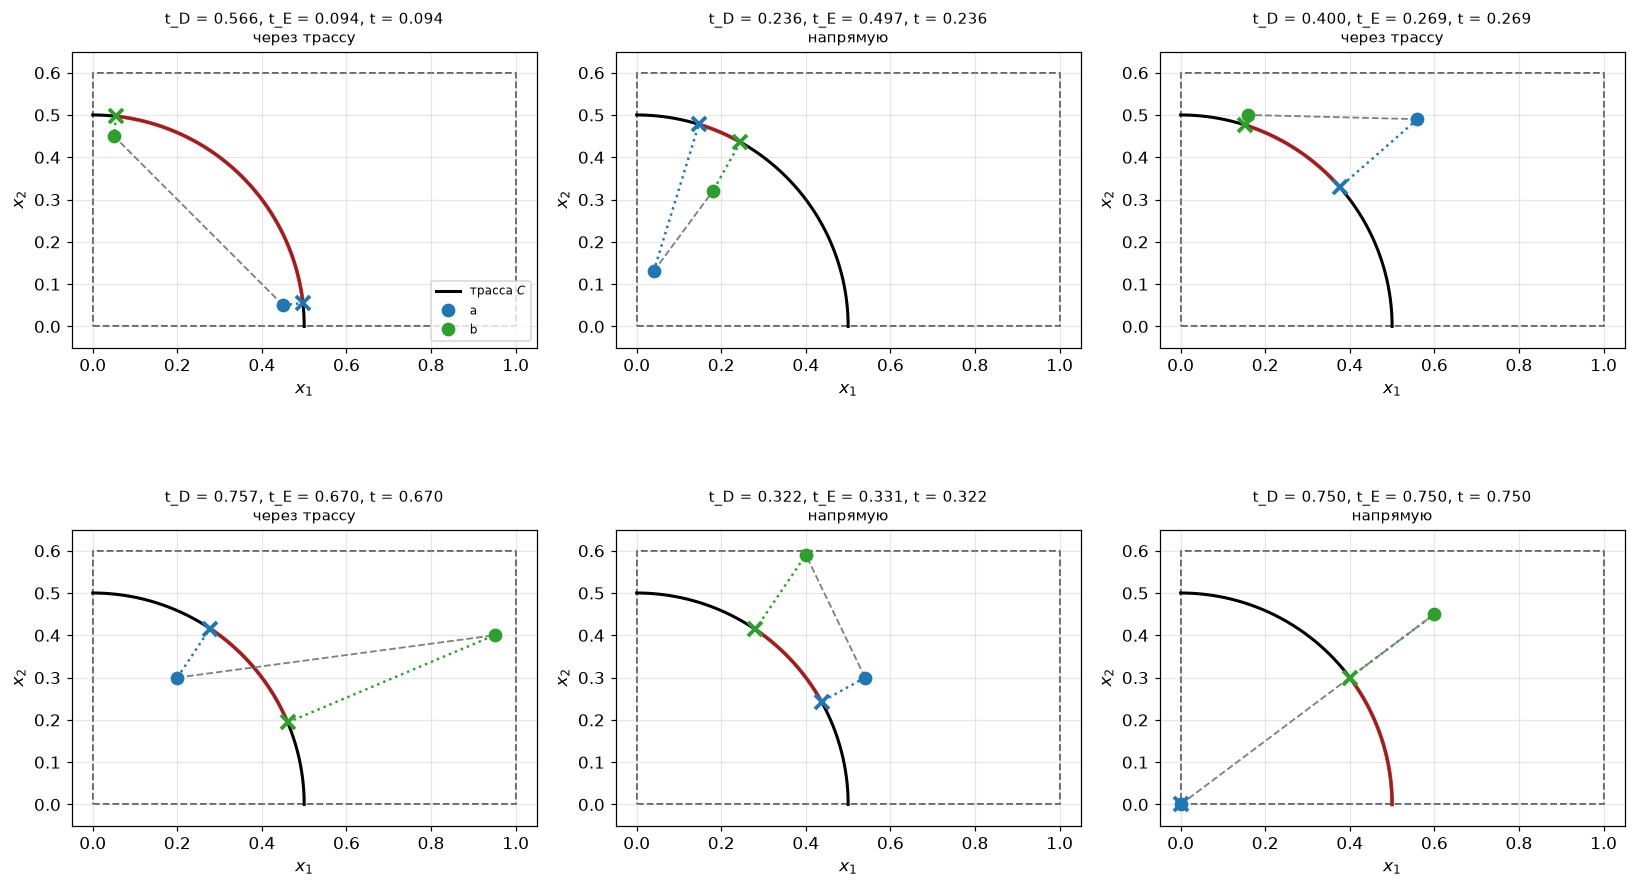

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (a1, a2, b1, b2) in zip(axes.ravel(), PAIRS):
    a, b = np.array([a1, a2]), np.array([b1, b2])
    at, bt = proj(a), proj(b)
    d, e = float(t_direct(a, b)), float(t_express(a, b))
    draw_setup(ax)
    ax.plot(*zip(a, at), color="tab:blue", ls=":", lw=1.6)
    ax.plot(*zip(bt, b), color="tab:green", ls=":", lw=1.6)
    th = np.linspace(np.arctan2(at[1], at[0]), np.arctan2(bt[1], bt[0]), 60)
    if th[-1] < th[0]:
        th += 2 * np.pi
    ax.plot(RAD * np.cos(th), RAD * np.sin(th), color="tab:red", lw=2.5, alpha=0.75)
    ax.plot(*zip(a, b), color="0.5", ls="--", lw=1.2)
    ax.plot(*a, "o", color="tab:blue", ms=8, label="a")
    ax.plot(*b, "o", color="tab:green", ms=8, label="b")
    ax.plot(*at, "x", color="tab:blue", ms=9, mew=2.5)
    ax.plot(*bt, "x", color="tab:green", ms=9, mew=2.5)
    ax.set_title(f"t_D = {d:.3f}, t_E = {e:.3f}, t = {min(d, e):.3f}\n"
                 f"{'через трассу' if e < d else 'напрямую'}", fontsize=10)
axes[0, 0].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

Замечания к таблице:

* №1: точки лежат почти на самой окружности ($\|a\|=\|b\|=0.4528$), поэтому
  вход на трассу и выход с неё почти не требуют времени, а расстояние по
  прямой вдвое больше — выигрыш почти $83\%$.
* №2, №5: точки далеко от окружности и недалеко друг от друга — трасса не нужна.
* №3, №4: точки по разные стороны окружности — трасса выигрывает.
* №6: $a=(0,0)$, расстояние до любой точки окружности равно $\tfrac12$, поэтому
  $t_E=0.5+0.25=0.75=t_D$ — прямой маршрут не хуже (равенство).

## b) Простое выражение для времени в пути

Так как $a_1,a_2\ge 0$, точка $a$ лежит в первой четверти, и её проекция на
окружность радиуса $\tfrac12$ тоже лежит на дуге $C$ внутри $R$: это
радиальная проекция
$$\tilde a=\tfrac12\,\frac{a}{\|a\|},$$
а расстояние до окружности равно
$$|a-\tilde a|=\bigl|\|a\|-\tfrac12\bigr|.$$
(то же верно для $b$). Поэтому

$$\boxed{\;t=\min\Bigl\{\sqrt{(a_1-b_1)^2+(a_2-b_2)^2},\
\bigl|\sqrt{a_1^2+a_2^2}-\tfrac12\bigr|+\bigl|\sqrt{b_1^2+b_2^2}-\tfrac12\bigr|\Bigr\}\;}$$

Трасса выгодна, когда
$$|a-b|>\bigl|\|a\|-\tfrac12\bigr|+\bigl|\|b\|-\tfrac12\bigr|,
$$
то есть когда точки далеко друг от друга, но обе близки к окружности
(например, лежат примерно на одной окружности, но в разных её частях).

## c) Среднее время в пути при равномерном распределении $a$ и $b$ в $R$

Оцениваем $\mathbb{E}t$ методом Монте-Карло: генерируем независимые равномерные
точки $a,b\in R$ и усредняем $t(a,b)$ (по формуле из пункта b).
Для контроля используем последовательность Соболя — дискрепансный метод
Монте-Карло с гораздо меньшей дисперсией при том же числе точек.

In [4]:
def sample_points(n, rng):
    """n независимых равномерных точек в R и n точек для b."""
    a = rng.random((n, 2)) * np.array([R_X, R_Y])
    b = rng.random((n, 2)) * np.array([R_X, R_Y])
    return a, b


N = 4_000_000
rng = np.random.default_rng(0)
a, b = sample_points(N, rng)
t = t_time(a, b)
tD, tE = t_direct(a, b), t_express(a, b)
share = float((tE < tD).mean())

print(f"Число пар: {N:,}")
print(f"E[t]      = {t.mean():.6f} +- {t.std(ddof=1) / np.sqrt(N):.6f}")
print(f"E[t_D]    = {tD.mean():.6f}  (без скоростной трассы)")
print(f"E[t_E]    = {tE.mean():.6f}  (всегда через трассу)")
print(f"Средняя экономия времени: {100 * (1 - t.mean() / tD.mean()):.1f}%")
print(f"Доля пар, где трасса быстрее: {share:.4f}")

# контроль: квази- Монте-Карло (последовательность Соболя)
U = qmc.Sobol(d=4, scramble=True, seed=7).random_base2(22)
a_s = np.column_stack([U[:, 0], R_Y * U[:, 1]])
b_s = np.column_stack([U[:, 2], R_Y * U[:, 3]])
t_s = t_time(a_s, b_s)
print(f"Соболь:   E[t] = {t_s.mean():.6f} +- {t_s.std(ddof=1) / np.sqrt(len(t_s)):.6f}")
print(f"Совпадение с обычным МК: {abs(t_s.mean() - t.mean()) / np.sqrt(t.std() / N + t_s.var() / len(t_s)):.2f} сигм")

Число пар: 4,000,000
E[t]      = 0.350438 +- 0.000095
E[t_D]    = 0.424010  (без скоростной трассы)
E[t_E]    = 0.465604  (всегда через трассу)
Средняя экономия времени: 17.4%
Доля пар, где трасса быстрее: 0.6117
Соболь:   E[t] = 0.350348 +- 0.000093
Совпадение с обычным МК: 0.38 сигм


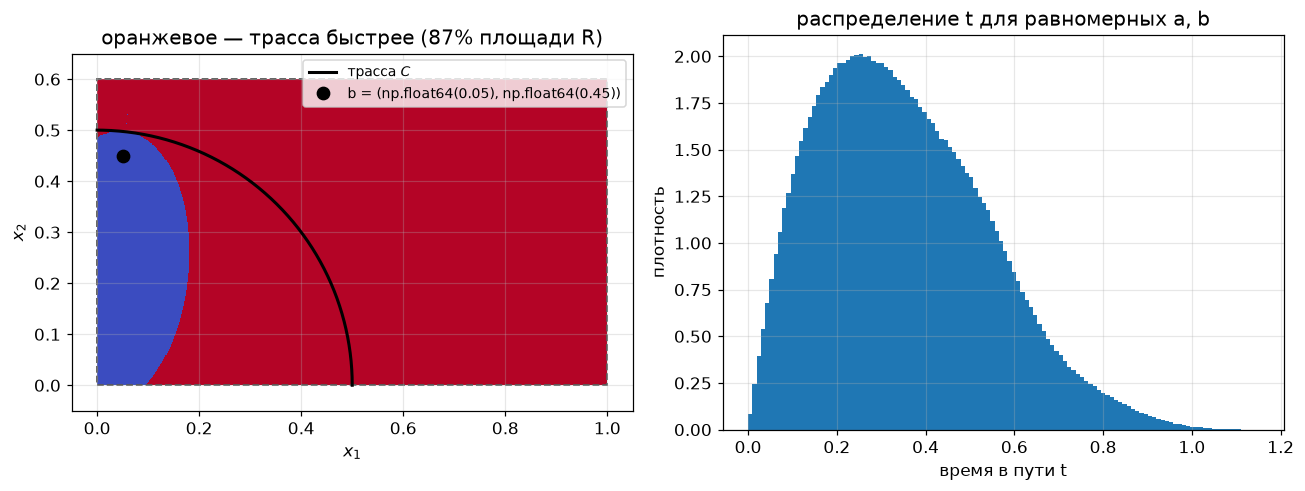

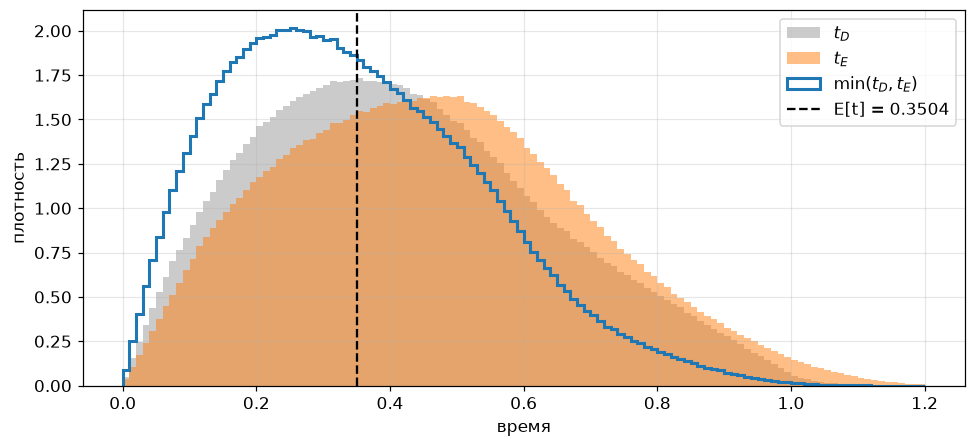

In [5]:
# геометрия выигрыша: при фиксированной точке b покажем область a, где трасса выгоднее
b0 = np.array([0.05, 0.45])
n = 500
g1 = (np.arange(n) + 0.5) / n
A1, A2 = np.meshgrid(g1, R_Y * g1, indexing="ij")
A = np.stack([A1, A2], -1).reshape(-1, 2)
use_express = (t_express(A, np.broadcast_to(b0, A.shape)) < t_direct(A, np.broadcast_to(b0, A.shape)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ax = axes[0]
ax.pcolormesh(A1, A2, use_express.reshape(n, n).astype(float), cmap="coolwarm",
              vmin=0, vmax=1, shading="auto")
draw_setup(ax)
ax.plot(*b0, "o", color="k", ms=8, label=f"b = {tuple(b0)}")
ax.set_title(f"оранжевое — трасса быстрее ({use_express.mean() * 100:.0f}% площади R)")
ax.legend(loc="upper right", fontsize=9)

ax = axes[1]
ax.hist(t, bins=120, color="tab:blue", density=True)
ax.set_xlabel("время в пути t")
ax.set_ylabel("плотность")
ax.set_title("распределение t для равномерных a, b")
plt.tight_layout()
plt.show()

# та же картина для всех пар: распределение t_D, t_E и min
fig, ax = plt.subplots(figsize=(9, 4.2))
bins = np.linspace(0, 1.2, 121)
ax.hist(tD, bins=bins, density=True, alpha=0.5, color="0.6", label="$t_D$")
ax.hist(tE, bins=bins, density=True, alpha=0.5, color="tab:orange", label="$t_E$")
ax.hist(t, bins=bins, density=True, histtype="step", lw=2, color="tab:blue",
        label=r"$\min(t_D, t_E)$")
ax.axvline(t.mean(), color="k", ls="--", label=f"E[t] = {t.mean():.4f}")
ax.set_xlabel("время")
ax.set_ylabel("плотность")
ax.legend()
plt.tight_layout()
plt.show()

### Выводы по заданию 3

* **a)** Времена в пути для шести пар из таблицы приведены выше; маршрут выбирается
  сравнением $t_D$ и $t_E$. В 3 случаях из 6 выигрывает скоростная трасса,
  в 2 — прямой маршрут, в 1 (пара №6) они равны.
* **b)** $t=\min\bigl(\|a-b\|,\;|\|a\|-\tfrac12|+|\|b\|-\tfrac12|\bigr)$ — расстояние
  до окружности зависит только от модуля вектора, поэтому проекция вычисляется
  в унарном виде.
* **c)** $\mathbb{E}t\approx 0.350$ против $0.424$ без трассы: окружная трасса
  снижает среднее время в пути примерно на $17\%$, причём в $61\%$ пар
  случайных точек она оказывается быстрее прямого маршрута. Оценка
  подтверждена методом Соболя. Заметим, что $t\le t_D$ и $t\le t_E$ всегда,
  поэтому $\mathbb{E}t$ заметно меньше обеих величин по отдельности.